# Infrastructure Failure Risk Prediction

This notebook loads the machine learning anomaly detection models trained in `Analysis.ipynb` and applies them to compute an aggregated **Structural Failure Risk Score**.

In [1]:
import pandas as pd
import numpy as np
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
mpl.style.use('dark_background')
sns.set_palette(['#00D4FF', '#FF6B35', '#7FFF00', '#FFD700', '#FF69B4', '#9B59B6'])

## 1. Define VAE Class & Load Models

In [2]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=8, latent_dim=2):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)
        self.fc22 = nn.Linear(hidden_dim, latent_dim)
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

print("Loading models...")
# Load Standard Scaler
scaler = joblib.load('models/scaler.pkl')
# Load Isolation Forest
iso_forest = joblib.load('models/isolation_forest.pkl')
# Load PyTorch VAE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = scaler.n_features_in_  # Dynamically pull the expected input shape
vae = VAE(input_dim).to(device)
vae.load_state_dict(torch.load('models/vae_state_dict.pth', map_location=device))
vae.eval() # Set to evaluation mode
print("Models loaded successfully!")

Loading models...
Models loaded successfully!


/tmp/ipykernel_102934/3538154176.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load('models/vae_state_dict.pth', map_location=device))


## 2. Load Streaming Data Chunk

In [3]:
# Let's simulate a streaming context by pulling the next 2000 rows 
# from digitaltwin.csv (e.g. rows 5000 to 7000) that the model hasn't specifically "seen" recently in demo.
DT_PATH = 'digitaltwin.csv'
dt_chunk = pd.read_csv(DT_PATH, skiprows=range(1, 5001), nrows=2000)
# Assuming columns are maintained. If the header is weird after skiprow, let's just load normally and slice.
dt_chunk = pd.read_csv(DT_PATH, parse_dates=['Timestamp']).iloc[5000:7000].reset_index(drop=True)

# ML Input features must match training exactly:
ml_features = ['Strain_microstrain', 'Deflection_mm', 'Vibration_ms2']
X_new = dt_chunk[ml_features].values
X_new_scaled = scaler.transform(X_new)
print(f"Loaded streaming data chunk shape: {X_new_scaled.shape}")

Loaded streaming data chunk shape: (2000, 3)


/home/ayush/Projects/portfolio/gallifrey/ml/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Compute Anomaly Component Scores

In [4]:
# 3.1 Isolation Forest Base Anomaly
# Preds are 1 (normal) or -1 (anomaly). Let's convert to an anomaly penalty: 1 for anomaly, 0 for normal.
iso_preds = iso_forest.predict(X_new_scaled)
iso_penalty = np.where(iso_preds == -1, 1, 0)

# 3.2 VAE Reconstruction Error
X_tensor = torch.tensor(X_new_scaled, dtype=torch.float32).to(device)
with torch.no_grad():
    recon_x, _, _ = vae(X_tensor)
    mse_loss = nn.MSELoss(reduction='none')
    # sum over the feature dimensions to get per-row error
    recon_errors = mse_loss(recon_x, X_tensor).sum(dim=1).cpu().numpy()

# Convert unbounded RE to a bounded (0-1) score using Min-Max or standard cutoff.
# We'll assume any RE > 5 is critically anomalous (scaling based on our training loss).
vae_score = np.clip(recon_errors / 5.0, 0, 1)
print("Computed Anomaly scores.")

Computed Anomaly scores.


## 4. Compute Final Risk Index
The **Risk Index (0-100)** combines the ML model structural health markers with external loading conditions (Wind and Traffic).

In [5]:
# Normalize environmental/traffic factors for Risk Equation
wind_normalized = np.clip(dt_chunk['Wind_Speed_ms'].values / 40.0, 0, 1) # max wind 40m/s
traffic_normalized = np.clip(dt_chunk['Traffic_Volume_vph'].values / 6000.0, 0, 1) # max traffic 6k vph

# The Risk Index Equation Formula
# 40% VAE Reconstruction Error (subtle systemic anomalies)
# 30% Isolation Forest Trigger (sudden multivariate outliers)
# 15% Wind Load
# 15% Traffic Load

risk_scores = (
    (vae_score * 40.0) + 
    (iso_penalty * 30.0) + 
    (wind_normalized * 15.0) +
    (traffic_normalized * 15.0)
)
dt_chunk['Computed_Risk_Score'] = risk_scores

def assign_risk_level(score):
    if score < 25:
        return 'Low'
    elif score < 50:
        return 'Medium'
    elif score < 75:
        return 'High'
    else:
        return 'Critical'
        
dt_chunk['Risk_Level'] = dt_chunk['Computed_Risk_Score'].apply(assign_risk_level)
print(dt_chunk['Risk_Level'].value_counts())

Risk_Level
Low         1408
Critical     447
High          77
Medium        68
Name: count, dtype: int64


## 5. Visualizing Risk Over Time

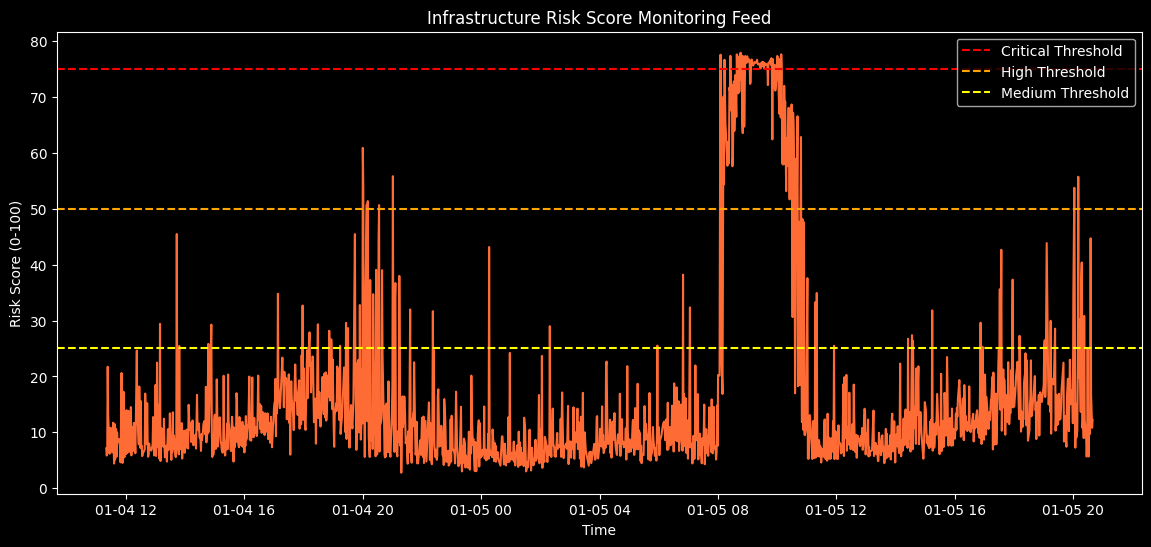

Found 447 critically flagged instances. Engineers notified.


In [6]:
plt.figure(figsize=(14, 6))
sns.lineplot(x='Timestamp', y='Computed_Risk_Score', data=dt_chunk, color='#FF6B35')
plt.axhline(75, color='red', linestyle='--', label='Critical Threshold')
plt.axhline(50, color='orange', linestyle='--', label='High Threshold')
plt.axhline(25, color='yellow', linestyle='--', label='Medium Threshold')
plt.title('Infrastructure Risk Score Monitoring Feed')
plt.ylabel('Risk Score (0-100)')
plt.xlabel('Time')
plt.legend()
plt.show()

# breakdown of VAE scores for the critical instances
critical = dt_chunk[dt_chunk['Risk_Level'] == 'Critical']
if not critical.empty:
    print(f"Found {len(critical)} critically flagged instances. Engineers notified.")
else:
    print("No critical risk instances found in this time window.")